# TFT

### Contents

1. [Colab](#Colab)
2. [Admin](#Admin)
3. [Config](#Config)
4. [Load](#Load)
5. [Batch_Builder](#Batch_Builder)
6. [Train_Dataset](#Train_Dataset)
7. [Eval_Dataset](#Eval_Dataset)
8. [Dataset_Smoke_Test](#Dataset_Smoke_Test)
9. [Embeddings](#Embeddings)
10. [Variable_Selection_Network](#Variable_Selection_Network)
11. [LSTM](#LSTM)
12. [Add_Norm](#Add_Norm)
13. [Gated_Residual_Network](#Gated_Residual_Network)
14. [Attention_Block](#Attention_Block)
15. [Output_Block](#Output_Block)
10. [TFT_Model](#TFT_Model)
11. [Model_Smoke_Test](#Model_Smoke_Test)
12. [Train_Function](#Train_Function)
13. [Validation_Function](#Validation_Function)
14. [Compile_Model](#Compîle_Model)
15. [Train_Loop](#Train_Loop)
16. [Plotting](#Plotting)
17. [Evaluation_Metrics](#Evaluation_Metrics)
18. [Prediction_Visualization](#Prediction_Visualization)
















change loss function
Log the target


### Colab

In [1]:
# =============================================================
# CELL 0 — OPTIONAL COLAB MOUNT
# =============================================================
# Uncomment when running on Colab.

from google.colab import drive
drive.mount("/content/drive")
%cd "/content/drive/MyDrive/M5"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/M5


### Admin

In [2]:
import io
import gc
import json
import time
import zipfile
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def move_batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(device, non_blocking=True)
        else:
            out[k] = v
    return out


def inspect_batch(batch, name="batch"):
    print(f"\n{name}")
    for k, v in batch.items():
        if torch.is_tensor(v):
            print(f"  {k:18s} shape={tuple(v.shape)} dtype={v.dtype}")
        else:
            print(f"  {k:18s} {v}")


torch.set_float32_matmul_precision("high")
set_seed(42)

device = get_device()
print("Device:", device)

Device: cuda


### Config


In [ ]:
class CFG:
    # paths
    # Resolve TFT repo root so the notebook works from different CWDs/hosts.
    try:
        TFT_ROOT = Path(__file__).resolve().parents[2]
    except NameError:
        p = Path.cwd()
        if (p / 'TFT').exists():
            TFT_ROOT = p / 'TFT'
        else:
            TFT_ROOT = p
            for _ in range(6):
                if (TFT_ROOT / 'monster_tensors_tft').exists() or (TFT_ROOT / 'src').exists():
                    break
                TFT_ROOT = TFT_ROOT.parent
    PROCESSED_DIR = TFT_ROOT / 'monster_tensors_tft'  # folder containing monster_*.zip

    # sequence setup
    CONTEXT = 56
    TARGET = 28
    PERIOD = CONTEXT + TARGET

    # training setup
    TRAIN_BATCH_SIZE = 256
    EVAL_BATCH_SIZE = 512

    # one "step" means:
    #   load random shard -> pull random block into RAM -> train all batches from that block
    SHARD_BLOCKS_PER_EPOCH = 40
    BLOCK_SIZE = 40000

    # model
    EMBEDDING_DIMS = {
        "product_id": 32,
        "department_id": 8,
        "category_id": 8,
        "store_id": 8,
        "state_code": 8,
    }

    HIDDEN_DIM = 128
    DROPOUT = 0.10

    # optimisation
    LR = 2e-4
    EPOCHS = 12
    GRAD_CLIP = 1.0

    # misc
    SEED = 42
    SAVE_DIR = Path("saved_weights_skeleton")


CFG.SAVE_DIR.mkdir(parents=True, exist_ok=True)

### Load

In [4]:
def load_npz_from_zip(zip_path: Path):
    """
    Load one zipped NPZ shard.

    Expected arrays:
      static_context
      historic_numeric
      known_numeric
      sales
      train_index
      valid_index
      test_index
    """
    with zipfile.ZipFile(zip_path, "r") as zf:
        npz_names = [n for n in zf.namelist() if n.endswith(".npz")]
        if not npz_names:
            raise FileNotFoundError(f"No .npz inside {zip_path}")
        with zf.open(npz_names[0]) as f:
            return np.load(io.BytesIO(f.read()), allow_pickle=False)


def list_shards(processed_dir: Path):
    files = sorted(processed_dir.glob("monster_*.zip"))
    files = [f for f in files if "DEBUG" not in f.name]

    if not files:
        # fallback: allow debug files while testing
        files = sorted(processed_dir.glob("*.zip"))

    if not files:
        raise FileNotFoundError(f"No zip shards found in {processed_dir}")

    return files


def inspect_shard_file(zip_path: Path):
    d = load_npz_from_zip(zip_path)
    print(f"\nShard: {zip_path.name}")
    for k in d.files:
        arr = d[k]
        print(f"  {k:24s} shape={arr.shape} dtype={arr.dtype}")
    d.close()


def infer_metadata_from_shards(processed_dir: Path, max_shards=None):
    """
    Infer cardinalities and dimensions from saved tensor shards.

    The static categorical order should be:
      product_id, department_id, category_id, store_id, state_code
    """
    files = list_shards(processed_dir)

    if max_shards is not None:
        files = files[:max_shards]

    # inspect first shard for dimensions / names
    d0 = load_npz_from_zip(files[0])

    static_cat_cols = (
        d0["static_cat_col_list"].astype(str).tolist()
        if "static_cat_col_list" in d0.files
        else ["product_id", "department_id", "category_id", "store_id", "state_code"]
    )

    hist_numeric_cols = (
        d0["hist_numeric_col_list"].astype(str).tolist()
        if "hist_numeric_col_list" in d0.files
        else ["sales", "price"]
    )

    known_cols = (
        d0["known_col_list"].astype(str).tolist()
        if "known_col_list" in d0.files
        else [f"known_{i}" for i in range(d0["known_numeric"].shape[-1])]
    )

    hist_dim = int(d0["historic_numeric"].shape[-1])
    known_dim = int(d0["known_numeric"].shape[-1])
    static_dim = int(d0["static_context"].shape[-1])

    d0.close()

    # infer cardinalities by max index + 1 over all shards
    max_ids = np.full(static_dim, -1, dtype=np.int64)

    print("[Metadata] inferring categorical cardinalities...")
    for path in tqdm(files, desc="scan shards"):
        d = load_npz_from_zip(path)
        sc = d["static_context"]
        max_ids = np.maximum(max_ids, sc.max(axis=0))
        d.close()
        gc.collect()

    cardinalities = {
        static_cat_cols[i]: int(max_ids[i] + 1)
        for i in range(static_dim)
    }

    meta = {
        "static_cat_cols": static_cat_cols,
        "hist_numeric_cols": hist_numeric_cols,
        "known_cols": known_cols,
        "cardinalities": cardinalities,
        "hist_dim": hist_dim,
        "known_dim": known_dim,
        "static_dim": static_dim,
        "num_shards": len(files),
    }

    print("\n[Metadata]")
    print(json.dumps({
        "static_cat_cols": meta["static_cat_cols"],
        "hist_numeric_cols": meta["hist_numeric_cols"],
        "hist_dim": meta["hist_dim"],
        "known_dim": meta["known_dim"],
        "cardinalities": meta["cardinalities"],
        "num_shards": meta["num_shards"],
    }, indent=2))

    return meta


shards = list_shards(CFG.PROCESSED_DIR)
print(f"Found {len(shards)} shard files")
inspect_shard_file(shards[0])

metadata = infer_metadata_from_shards(CFG.PROCESSED_DIR)

Found 10 shard files

Shard: monster_CA_1.zip
  static_context           shape=(3049, 5) dtype=int16
  historic_numeric         shape=(3049, 1941, 2) dtype=float32
  known_numeric            shape=(3049, 1941, 75) dtype=float32
  sales                    shape=(3049, 1941) dtype=float32
  day_nums                 shape=(3049, 1941) dtype=int32
  series_ids               shape=(3049,) dtype=<U31
  train_index              shape=(737858, 2) dtype=int32
  valid_index              shape=(3049, 2) dtype=int32
  test_index               shape=(3049, 2) dtype=int32
  known_col_list           shape=(75,) dtype=<U32
  hist_numeric_col_list    shape=(2,) dtype=<U5
  static_cat_col_list      shape=(5,) dtype=<U13
  split_boundaries_json    shape=() dtype=<U185
[Metadata] inferring categorical cardinalities...


scan shards:   0%|          | 0/10 [00:00<?, ?it/s]


[Metadata]
{
  "static_cat_cols": [
    "product_id",
    "department_id",
    "category_id",
    "store_id",
    "state_code"
  ],
  "hist_numeric_cols": [
    "sales",
    "price"
  ],
  "hist_dim": 2,
  "known_dim": 75,
  "cardinalities": {
    "product_id": 3049,
    "department_id": 7,
    "category_id": 3,
    "store_id": 10,
    "state_code": 3
  },
  "num_shards": 10
}


### Batch_Builder

In [5]:
def build_batches_from_rows(d, rows, batch_size, shard_name):
    """
    Create torch batches from index rows.

    Arrays in d:
      static_context   [S, 5]
      historic_numeric [S, T, 2] = sales, price
      known_numeric    [S, T, K]
      sales            [S, T]

    Index row:
      [s_idx, t_idx]

    Slicing:
      past_numeric  = historic_numeric[s, t-56:t, :]
      past_known    = known_numeric[s, t-56:t, :]
      future_known  = known_numeric[s, t:t+28, :]
      future_price  = historic_numeric[s, t:t+28, 1:2]
      target        = sales[s, t:t+28]
    """
    c = CFG.CONTEXT
    h = CFG.TARGET

    static_context = d["static_context"]
    historic_numeric = d["historic_numeric"]
    known_numeric = d["known_numeric"]
    sales = d["sales"]

    batches = []

    for start in range(0, len(rows), batch_size):
        chunk = rows[start:start + batch_size]

        s_idx = chunk[:, 0].astype(np.int64)
        t_idx = chunk[:, 1].astype(np.int64)

        idx_context = t_idx[:, None] - c + np.arange(c)[None, :]
        idx_target = t_idx[:, None] + np.arange(h)[None, :]

        batch = {
            # static categorical embedding IDs
            "static_cats": torch.from_numpy(static_context[s_idx]).long(),

            # encoder inputs
            "past_numeric": torch.from_numpy(
                historic_numeric[s_idx[:, None], idx_context, :]
            ).float(),

            "past_known": torch.from_numpy(
                known_numeric[s_idx[:, None], idx_context, :]
            ).float(),

            # decoder/future known inputs
            "future_known": torch.from_numpy(
                known_numeric[s_idx[:, None], idx_target, :]
            ).float(),

            "future_price": torch.from_numpy(
                historic_numeric[s_idx[:, None], idx_target, 1:2]
            ).float(),

            # target
            "target": torch.from_numpy(
                sales[s_idx[:, None], idx_target]
            ).float(),

            # debugging / traceability
            "file": shard_name,
            "series_idx": torch.from_numpy(s_idx).long(),
            "t_idx": torch.from_numpy(t_idx).long(),
        }

        batches.append(batch)

    return batches

### Train_Dataset

In [6]:
class RandomShardBlockDataset:
    """
    Training dataset wrapper.

    Logic:
      1. Randomly select one shard.
      2. Load that shard.
      3. Copy and shuffle that shard's train_index.
      4. Take the first BLOCK_SIZE rows as the RAM block.
      5. Build all batches from that block.
      6. Outer training loop repeats this SHARD_BLOCKS_PER_EPOCH times.

    This avoids slower random row selection via rng.choice while still giving
    randomly mixed training rows.

    Saved index semantics:
      row = [series_idx, t_idx]

      context = t_idx - 56 : t_idx
      target  = t_idx      : t_idx + 28
    """

    def __init__(
        self,
        processed_dir,
        split="train",
        batch_size=128,
        blocks_per_epoch=30,
        block_size=20000,
        seed=42,
    ):
        assert split == "train", "Use EvalShardDataset for valid/test"

        self.processed_dir = Path(processed_dir)
        self.files = list_shards(self.processed_dir)

        self.split = split
        self.batch_size = int(batch_size)
        self.blocks_per_epoch = int(blocks_per_epoch)
        self.block_size = int(block_size)

        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return self.blocks_per_epoch

    def get_block_batches(self, _step_idx=None):
        shard_path = self.rng.choice(self.files)

        t0 = time.perf_counter()
        d = load_npz_from_zip(shard_path)
        t1 = time.perf_counter()

        print(f"\n[TRAIN] loaded {shard_path.name} in {t1 - t0:.3f}s")

        index = d["train_index"]
        n = len(index)

        if n == 0:
            d.close()
            raise ValueError(f"No train windows in {shard_path.name}")

        take = min(self.block_size, n)

        # Faster random block:
        # copy full index, shuffle rows in-place, then take contiguous prefix.
        rows = index.copy()
        self.rng.shuffle(rows)
        rows = rows[:take]

        batches = build_batches_from_rows(
            d=d,
            rows=rows,
            batch_size=self.batch_size,
            shard_name=shard_path.name,
        )

        d.close()
        gc.collect()

        print(f"[TRAIN] {len(rows):,} shuffled samples -> {len(batches):,} batches")
        return batches

### Eval_Dataset

In [7]:
class EvalShardDataset:
    """
    Validation/test wrapper.

    Logic:
      iterate shards sequentially.
      each shard returns all valid/test batches.
    """

    def __init__(self, processed_dir, split="valid", batch_size=256):
        assert split in {"valid", "test"}

        self.processed_dir = Path(processed_dir)
        self.files = list_shards(self.processed_dir)

        self.split = split
        self.batch_size = int(batch_size)

    def __len__(self):
        return len(self.files)

    def get_shard_batches(self, shard_idx):
        shard_path = self.files[shard_idx]

        t0 = time.perf_counter()
        d = load_npz_from_zip(shard_path)
        t1 = time.perf_counter()

        print(f"\n[{self.split.upper()}] loaded {shard_path.name} in {t1 - t0:.3f}s")

        rows = d[f"{self.split}_index"]

        batches = build_batches_from_rows(
            d=d,
            rows=rows,
            batch_size=self.batch_size,
            shard_name=shard_path.name,
        )

        d.close()
        gc.collect()

        print(f"[{self.split.upper()}] {len(rows):,} samples -> {len(batches):,} batches")
        return batches

### Dataset_Smoke_Test

In [8]:
train_ds = RandomShardBlockDataset(
    processed_dir=CFG.PROCESSED_DIR,
    batch_size=CFG.TRAIN_BATCH_SIZE,
    blocks_per_epoch=1,
    block_size=1024,
    seed=CFG.SEED,
)

test_batches = train_ds.get_block_batches()
batch = test_batches[0]
inspect_batch(batch, "smoke-test batch")


[TRAIN] loaded monster_CA_1.zip in 7.396s
[TRAIN] 1,024 shuffled samples -> 4 batches

smoke-test batch
  static_cats        shape=(256, 5) dtype=torch.int64
  past_numeric       shape=(256, 56, 2) dtype=torch.float32
  past_known         shape=(256, 56, 75) dtype=torch.float32
  future_known       shape=(256, 28, 75) dtype=torch.float32
  future_price       shape=(256, 28, 1) dtype=torch.float32
  target             shape=(256, 28) dtype=torch.float32
  file               monster_CA_1.zip
  series_idx         shape=(256,) dtype=torch.int64
  t_idx              shape=(256,) dtype=torch.int64


In [9]:
from pathlib import Path

def count_train_windows(processed_dir):
    processed_dir = Path(processed_dir)
    files = list_shards(processed_dir)

    total = 0
    per_shard = {}

    for shard_path in files:
        d = load_npz_from_zip(shard_path)
        n = len(d["train_index"])
        per_shard[shard_path.name] = n
        total += n
        d.close()

    return total, per_shard

total_train, per_shard = count_train_windows(train_ds.processed_dir)
print("Total train windows:", total_train)
print("Per shard:", per_shard)

Total train windows: 7378580
Per shard: {'monster_CA_1.zip': 737858, 'monster_CA_2.zip': 737858, 'monster_CA_3.zip': 737858, 'monster_CA_4.zip': 737858, 'monster_TX_1.zip': 737858, 'monster_TX_2.zip': 737858, 'monster_TX_3.zip': 737858, 'monster_WI_1.zip': 737858, 'monster_WI_2.zip': 737858, 'monster_WI_3.zip': 737858}


### Embeddings

In [10]:
class StaticEmbeddingBlock(nn.Module):
    """
    Turns static categorical IDs into one concatenated embedding vector.

    Input:
      static_cats: [B, 5]

    Output:
      static_emb: [B, sum_embedding_dims]
    """

    def __init__(self, cardinalities, embedding_dims, static_cat_cols):
        super().__init__()

        self.static_cat_cols = list(static_cat_cols)

        self.embeddings = nn.ModuleDict()

        for name in self.static_cat_cols:
            card = int(cardinalities[name])
            dim = int(embedding_dims[name])
            self.embeddings[name] = nn.Embedding(card, dim)

        self.out_dim = sum(int(embedding_dims[name]) for name in self.static_cat_cols)

    def forward(self, static_cats):
        embs = []

        for i, name in enumerate(self.static_cat_cols):
            x = static_cats[:, i]
            embs.append(self.embeddings[name](x))

        return torch.cat(embs, dim=-1)

### Variable_Selection_Network

In [11]:
import torch.nn.functional as F


class VariableSelectionNetwork(nn.Module):
    """
    VSN over raw concatenated past features.

    Inputs:
      - raw_past:       [B, T, raw_dim]   where raw_dim = hist_dim + known_dim (e.g. 77)
      - static_context: [B, static_dim]

    Outputs:
      - weighted_raw_past: [B, T, raw_dim]
      - agg_weights:       [B, raw_dim]  (mean over time)
    """

    def __init__(self, raw_dim, static_context_dim, dropout=0.1):
        super().__init__()

        self.raw_dim = raw_dim
        self.raw_proj = nn.Linear(raw_dim, raw_dim)

        # c0: static -> model-dim (raw_dim) then broadcast across time
        self.context_proj = nn.Linear(static_context_dim, raw_dim)

        # keep everything in raw_dim so weights are directly applied to raw features
        self.n2_proj = nn.Linear(raw_dim, raw_dim)
        self.gate_proj = nn.Linear(raw_dim, raw_dim)
        self.signal_proj = nn.Linear(raw_dim, raw_dim)

        self.add_norm = nn.LayerNorm(raw_dim)
        self.soft_prep = nn.Linear(raw_dim, raw_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, raw_past, static_context):
        """
        raw_past: [B, T, raw_dim]
        static_context: [B, static_dim]
        """
        # t0 (raw) is the thing we will weight 1:1
        t0 = raw_past  # [B, T, raw_dim]

        # broadcast static context to all timesteps
        c0 = self.context_proj(static_context)              # [B, raw_dim]
        c0 = c0.unsqueeze(1).expand(-1, t0.shape[1], -1)   # [B, T, raw_dim]

        # n2 / gating path (still in raw_dim)
        n2 = F.elu(self.raw_proj(t0)+ c0)                  # [B, T, raw_dim]
        n2 = self.dropout(n2)
        n1 = self.n2_proj(n2)                              # [B, T, raw_dim]

        glu_n1 = torch.sigmoid(self.gate_proj(n1)) * self.signal_proj(n1)  # [B, T, raw_dim]
        out = self.add_norm(t0 + glu_n1)                   # [B, T, raw_dim]


        # weights over raw feature dimensions
        w_t = F.softmax(self.soft_prep(out), dim=-1)       # [B, T, raw_dim]

        # apply weights to raw inputs
        weighted_raw_past = raw_past * w_t                # [B, T, raw_dim]

        # aggregate for the app (only)
        agg_weights = w_t.mean(dim=1)                     # [B, raw_dim]

        return weighted_raw_past, agg_weights

### LSTM

In [12]:
class LSTMBlock(nn.Module):
    """
    Encoder-decoder LSTM block.

    Inputs:
        past_seq:   [B, 56, hidden_dim]
        future_seq:  [B, 28, hidden_dim]
        static_ctx:  [B, static_dim]

    Output:
        full_seq:    [B, 84, hidden_dim]
    """

    def __init__(self, input_dim, hidden_dim, static_dim, dropout=0.1, num_layers=1):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.static_dim = static_dim
        self.num_layers = num_layers

        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        self.decoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

        # static context -> initial encoder hidden/cell state
        self.init_h = nn.Linear(static_dim, hidden_dim) # hidden state
        self.init_c = nn.Linear(static_dim, hidden_dim) # cell state, same but with a license to be different

    def forward(self, past_seq, future_seq, static_ctx):
        B = past_seq.shape[0]

        # [B, hidden_dim] -> [num_layers, B, hidden_dim]
        h0 = self.init_h(static_ctx).unsqueeze(0).repeat(self.num_layers, 1, 1) # [Layers x B x 128]
        c0 = self.init_c(static_ctx).unsqueeze(0).repeat(self.num_layers, 1, 1) # [Layers x B x 128]

        enc_out, (h_n, c_n) = self.encoder(past_seq, (h0, c0))
        dec_out, _ = self.decoder(future_seq, (h_n, c_n))

        full_seq = torch.cat([enc_out, dec_out], dim=1)  # [B, 84, hidden_dim]
        return full_seq


### Add_Norm

In [13]:
class AddNormBlock(nn.Module):
    def __init__(self, hidden_dim, dropout=0.1):
        super().__init__()
        self.signal_proj = nn.Linear(hidden_dim, hidden_dim)
        self.gate_proj = nn.Linear(hidden_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, residual, transformed):
        gate = F.sigmoid(self.gate_proj(transformed))
        signal = self.signal_proj(transformed)
        gated = gate * signal
        gated = self.dropout(gated)
        return self.layer_norm(residual + gated)

### Gated_Residual_Network

In [14]:
class GatedResidualNetwork(nn.Module):
    def __init__(self, hidden_dim, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(hidden_dim, hidden_dim)
        self.context_proj = nn.Linear(hidden_dim, hidden_dim)
        self.mix_proj = nn.Linear(hidden_dim, hidden_dim)

        self.signal_proj = nn.Linear(hidden_dim, hidden_dim)
        self.gate_proj = nn.Linear(hidden_dim, hidden_dim)

        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def forward(self, x, context):
        z = torch.nn.functional.elu(
            self.input_proj(x) + self.context_proj(context)
        )
        z = self.mix_proj(z)

        signal = self.signal_proj(z)
        gate = torch.sigmoid(self.gate_proj(z))

        gated = gate * signal
        gated = self.dropout(gated)

        return self.layer_norm(x + gated)

### Attention_Block

In [15]:
import math

class AttentionBlock(nn.Module):
    """
    Explicit multi-head self-attention block.

    - No mask
    - No shared value projection
    - Each head uses full hidden_dim
    - Heads are computed one by one in a loop
    - Concatenate heads and project back to hidden_dim
    """

    def __init__(self, hidden_dim=128, num_heads=4, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_heads = num_heads

        self.heads = nn.ModuleList([
            nn.ModuleDict({
                "q": nn.Linear(hidden_dim, hidden_dim),
                "k": nn.Linear(hidden_dim, hidden_dim),
                "v": nn.Linear(hidden_dim, hidden_dim),
            })
            for _ in range(num_heads)
        ])

        self.out_proj = nn.Linear(hidden_dim * num_heads, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(hidden_dim)

    def forward(self, x, return_weights=False):
        """
        x: [B, T, H]
        returns:
            out: [B, T, H]
            attn_weights (optional): [B, num_heads, T, T]
        """
        B, T, H = x.shape
        assert H == self.hidden_dim, f"Expected hidden_dim={self.hidden_dim}, got {H}"

        residual = x
        head_outputs = []
        head_weights = []

        for head in self.heads:
            q = head["q"](x)  # [B, T, H]
            k = head["k"](x)  # [B, T, H]
            v = head["v"](x)  # [B, T, H]

            # scores: [B, T, T]
            scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(H) # swap last 2 dims, not the batch
            weights = torch.softmax(scores, dim=-1)
            weights = self.dropout(weights)

            # output: [B, T, H]
            out = torch.matmul(weights, v)

            head_outputs.append(out)
            head_weights.append(weights)

        # concatenate heads: [B, T, num_heads * H]
        concat = torch.cat(head_outputs, dim=-1)

        # back to hidden_dim: [B, T, H]
        out = self.out_proj(concat)
        out = self.dropout(out)

        # residual + norm
        out = self.norm(residual + out)

        return out

### Output_Block

In [16]:
class OutputBlock(nn.Module):
    """
    TFT-style output block:
    - Add & Norm over attention output
    - context-aware GRN
    - Add & Norm
    - per-timestep dense prediction head
    """

    def __init__(self, hidden_dim, dropout=0.1, out_dim=1):
        super().__init__()

        self.add_norm_1 = AddNormBlock(hidden_dim=hidden_dim, dropout=dropout)
        self.grn = GatedResidualNetwork(hidden_dim=hidden_dim, dropout=dropout)
        self.add_norm_2 = AddNormBlock(hidden_dim=hidden_dim, dropout=dropout)

        self.pred_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, out_dim),
        )

    def forward(self, residual, attn_out, static_context_all):
        """
        residual:          [B, T, H]
        attn_out:          [B, T, H]
        static_context_all:[B, T, H]
        """
        x = self.add_norm_1(residual=residual, transformed=attn_out)
        grn_out = self.grn(x, static_context_all)
        x = self.add_norm_2(residual=x, transformed=grn_out)
        pred = self.pred_head(x)
        return pred

### TFT_Model

In [17]:
class TFTModel(nn.Module):
    """
    Skeleton TFT-style model:
    - VSN over raw past concat
    - past/future projection to model dim
    - encoder-decoder LSTM
    - attention
    - decoder-only output block
    """

    def __init__(
        self,
        metadata,
        embedding_dims,
        hidden_dim=128,
        dropout=0.1,
    ):
        super().__init__()

        self.context = CFG.CONTEXT
        self.target = CFG.TARGET

        self.static_cat_cols = metadata["static_cat_cols"]
        self.hist_dim = metadata["hist_dim"]
        self.known_dim = metadata["known_dim"]

        self.static_block = StaticEmbeddingBlock(
            cardinalities=metadata["cardinalities"],
            embedding_dims=embedding_dims,
            static_cat_cols=self.static_cat_cols,
        )
        static_dim = self.static_block.out_dim

        # Normalise per timestep features
        self.norm_past_numeric = nn.LayerNorm(self.hist_dim)
        self.norm_past_known = nn.LayerNorm(self.known_dim)
        self.norm_future_known = nn.LayerNorm(self.known_dim)

        # VSN over raw past concat
        raw_past_dim = self.hist_dim + self.known_dim
        self.vsn = VariableSelectionNetwork(
            raw_dim=raw_past_dim,
            static_context_dim=static_dim,
            dropout=dropout,
        )

        # Project whole past block and future block into model dim
        self.past_proj = nn.Linear(raw_past_dim, hidden_dim)
        self.future_proj = nn.Linear(self.known_dim + 1, hidden_dim)

        # LSTM block
        self.lstm_block = LSTMBlock(
            input_dim=hidden_dim,
            hidden_dim=hidden_dim,
            static_dim=static_dim,
            dropout=dropout,
            num_layers=2,
        )

        # Add Norm block
        self.add_norm = AddNormBlock(hidden_dim=hidden_dim, dropout=dropout)

        # Gated Residual Network
        self.static_stretch = nn.Linear(static_dim, hidden_dim)
        self.grn = GatedResidualNetwork(hidden_dim=hidden_dim, dropout=dropout)

        # Attention block
        self.attn = AttentionBlock(hidden_dim=hidden_dim, num_heads=4, dropout=dropout)

        # Decoder-only output block
        self.output_block = OutputBlock(
            hidden_dim=hidden_dim,
            dropout=dropout,
            out_dim=1,
        )

        self._init_weights()

    def _init_weights(self):
        def init_fn(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

            elif isinstance(m, nn.Embedding):
                nn.init.normal_(m.weight, mean=0.0, std=0.02)

            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

            elif isinstance(m, nn.LSTM):
                for name, param in m.named_parameters():
                    if "weight_ih" in name:
                        nn.init.xavier_uniform_(param.data)
                    elif "weight_hh" in name:
                        nn.init.orthogonal_(param.data)
                    elif "bias" in name:
                        nn.init.zeros_(param.data)

        self.apply(init_fn)

    def forward(self, batch):
        static_cats = batch["static_cats"]       # [B, 5]
        past_numeric = batch["past_numeric"]     # [B, 56, 2]
        past_known = batch["past_known"]         # [B, 56, 75]
        future_known = batch["future_known"]     # [B, 28, 75]
        future_price = batch["future_price"]     # [B, 28, 1]

        # safety
        past_numeric = torch.nan_to_num(past_numeric, nan=0.0, posinf=0.0, neginf=0.0)
        past_known = torch.nan_to_num(past_known, nan=0.0, posinf=0.0, neginf=0.0)
        future_known = torch.nan_to_num(future_known, nan=0.0, posinf=0.0, neginf=0.0)
        future_price = torch.nan_to_num(future_price, nan=0.0, posinf=0.0, neginf=0.0)

        H = future_known.shape[1]  # forecast horizon

        # static embeddings
        static_emb = self.static_block(static_cats)   # [B, static_dim]
        static_emb_small = static_emb * 0.1

        # normalize past
        past_numeric = self.norm_past_numeric(past_numeric)
        past_known = self.norm_past_known(past_known)

        # raw concat outside VSN
        raw_past = torch.cat([past_numeric, past_known], dim=-1)  # [B, 56, 77]

        # VSN over raw past
        weighted_raw_past, agg_weights = self.vsn(raw_past, static_emb_small)

        # project whole past block to model dim
        past_h = self.past_proj(weighted_raw_past)  # [B, 56, hidden_dim]

        # future side: normalize known, concat price, project
        future_known = self.norm_future_known(future_known)
        future_raw = torch.cat([future_known, future_price], dim=-1)  # [B, 28, hidden_dim-ish]
        future_h = self.future_proj(future_raw)                       # [B, 28, hidden_dim]

        # LSTM encoder-decoder
        lstm_out = self.lstm_block(past_h, future_h, static_emb_small)  # [B, 84, hidden_dim]

        # Add Norm block
        normed = self.add_norm(
            residual=torch.cat([past_h, future_h], dim=1),
            transformed=lstm_out,
        )  # [B, 84, hidden_dim]

        # Static enrichment
        static_emb_all = self.static_stretch(
            static_emb_small.unsqueeze(1).expand(-1, normed.size(1), -1)
        )  # [B, 84, hidden_dim]

        grn_out = self.grn(normed, static_emb_all)  # [B, 84, hidden_dim]

        # Attention
        attn_out = self.attn(grn_out)  # [B, 84, hidden_dim]

        # Decoder-only slices
        future_residual = grn_out[:, -H:, :]
        future_attn_out = attn_out[:, -H:, :]
        future_context = static_emb_all[:, -H:, :]

        # Output block
        pred_seq = self.output_block(
            residual=future_residual,
            attn_out=future_attn_out,
            static_context_all=future_context,
        )  # [B, 28, 1]

        pred = pred_seq.squeeze(-1)  # [B, 28]

        return pred, agg_weights

    @property
    def params(self) -> str:
        def count_params(mod: nn.Module) -> int:
            return sum(p.numel() for p in mod.parameters())

        pre_vsn_mods = [self.static_block, self.norm_past_numeric, self.norm_past_known]
        vsn_mods = [self.vsn]
        lstm_mods = [self.past_proj, self.future_proj, self.lstm_block]
        enrich_mods = [self.add_norm, self.static_stretch, self.grn]
        attn_mods = [self.attn]
        output_mods = [self.output_block]

        pre_vsn = sum(count_params(m) for m in pre_vsn_mods)
        vsn = sum(count_params(m) for m in vsn_mods)
        lstm = sum(count_params(m) for m in lstm_mods)
        enrichment = sum(count_params(m) for m in enrich_mods)
        attention = sum(count_params(m) for m in attn_mods)
        output = sum(count_params(m) for m in output_mods)

        total = sum(p.numel() for p in self.parameters())

        lines = [
            f"{self.__class__.__name__} parameter totals",
            f"Total parameters: {total:,}",
            "",
            f"pre_vsn: {pre_vsn:,}",
            f"vsn: {vsn:,}",
            f"lstm: {lstm:,}",
            f"enrichment: {enrichment:,}",
            f"attention: {attention:,}",
            f"output_block: {output:,}",
        ]
        return "\n".join(lines)

### Model_Smoke_Test

In [18]:
# build model
model = TFTModel(
    metadata=metadata,
    embedding_dims=CFG.EMBEDDING_DIMS,
    hidden_dim=CFG.HIDDEN_DIM,
    dropout=CFG.DROPOUT,
).to(device)

print('\n----- Params -----')
print(model.params)
print('\n----- ----- -----\n')


batch_dev = move_batch_to_device(batch, device)

with torch.no_grad():
    pred, agg_weights = model(batch_dev)

print("Prediction shape:", pred.shape)                 # [B, 28]
print("Target shape    :", batch_dev["target"].shape) # [B, 28]
print("Agg weights shape:", agg_weights.shape)        # [B, 77]

loss_fn = nn.MSELoss()
loss = loss_fn(pred, batch_dev["target"])
print("Smoke loss:", float(loss.item()))

# basic asserts (optional)
B = batch_dev["static_cats"].shape[0]
assert pred.shape == batch_dev["target"].shape
assert agg_weights.shape[0] == B
print("Smoke test passed. Tensor goblins contained (mostly).")


----- Params -----
TFTModel parameter totals
Total parameters: 1,260,798

pre_vsn: 97,906
vsn: 35,189
lstm: 564,864
enrichment: 124,416
attention: 264,064
output_block: 174,209

----- ----- -----

Prediction shape: torch.Size([256, 28])
Target shape    : torch.Size([256, 28])
Agg weights shape: torch.Size([256, 77])
Smoke loss: 17.4529972076416
Smoke test passed. Tensor goblins contained (mostly).


In [19]:
torch.isfinite(pred).all()

tensor(True, device='cuda:0')

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SpikeAwareAsymmetricMSELoss(nn.Module):
    def __init__(
        self,
        pos_alpha=0.25,     # mild boost for positive targets
        zero_weight=0.2,    # zeros still matter, but less
        under_weight=1.05,  # slight penalty for underprediction
        over_weight=0.98,   # tiny preference for overprediction
        max_weight=3.0,
        eps=1e-6,
        reduction="mean",
    ):
        super().__init__()
        self.pos_alpha = pos_alpha
        self.zero_weight = zero_weight
        self.under_weight = under_weight
        self.over_weight = over_weight
        self.max_weight = max_weight
        self.eps = eps
        self.reduction = reduction

    def forward(self, pred, target):
        target = torch.nan_to_num(target, nan=0.0, posinf=0.0, neginf=0.0).clamp_min(0.0)

        # keep predictions nonnegative for sales
        pred_pos = F.softplus(pred)

        # base MSE
        base_loss = (pred_pos - target).pow(2)

        # small emphasis on non-zero sales
        weight = torch.where(
            target > 0,
            1.0 + self.pos_alpha * torch.sqrt(target + self.eps),
            torch.full_like(target, self.zero_weight),
        )

        # very slight preference for overprediction
        asym = torch.where(
            pred_pos < target,
            torch.full_like(target, self.under_weight),
            torch.full_like(target, self.over_weight),
        )

        loss = base_loss * weight * asym
        loss = loss.clamp(max=self.max_weight * 1e6)

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss

### Train_Function

In [21]:
def train_one_epoch(model, train_ds, optimizer, loss_fn, device, verbose=True):
    model.train()

    use_amp = device.type == "cuda"
    amp_dtype = torch.bfloat16 if use_amp else torch.float32

    total_loss = 0.0
    total_sq = 0.0
    total_abs = 0.0
    total_points = 0
    total_batches = 0
    total_examples = 0

    iterator = range(len(train_ds))
    if verbose:
        iterator = tqdm(iterator, desc="Train blocks", leave=False)

    for block_i in iterator:
        batches = train_ds.get_block_batches(block_i)

        for batch in batches:
            batch = move_batch_to_device(batch, device)
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type=device.type,
                dtype=amp_dtype,
                enabled=use_amp,
            ):
                pred, agg_weights = model(batch)
                target = batch["target"]
                loss = loss_fn(pred, target)

            if not torch.isfinite(loss):
                print("[Warn] non-finite loss skipped")
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
            optimizer.step()

            # training loss
            total_loss += float(loss.item())

            # raw-scale metrics for reporting
            pred_sales = F.softplus(pred)
            diff = pred_sales - target
            total_sq += float((diff ** 2).sum().item())
            total_abs += float(diff.abs().sum().item())
            total_points += int(target.numel())

            total_batches += 1
            total_examples += int(target.shape[0])

        del batches
        gc.collect()

    mean_loss = total_loss / max(total_batches, 1)
    mse = total_sq / max(total_points, 1)
    mae = total_abs / max(total_points, 1)
    rmse = float(np.sqrt(mse))

    return {
        "loss": mean_loss,   # huber-based training loss
        "mse": float(mse),   # raw-scale metric
        "mae": float(mae),   # raw-scale metric
        "rmse": rmse,        # raw-scale metric
        "batches": total_batches,
        "examples": total_examples,
    }

### Validation_Function

In [22]:
@torch.no_grad()
def evaluate(model, eval_ds, loss_fn, device, verbose=True):
    model.eval()

    total_loss = 0.0
    total_sq = 0.0
    total_abs = 0.0
    total_points = 0
    total_batches = 0

    per_day_sq = np.zeros(CFG.TARGET, dtype=np.float64)
    per_day_abs = np.zeros(CFG.TARGET, dtype=np.float64)
    n_series = 0

    iterator = range(len(eval_ds))
    if verbose:
        iterator = tqdm(iterator, desc=f"Eval-{eval_ds.split}", leave=False)

    for shard_i in iterator:
        batches = eval_ds.get_shard_batches(shard_i)

        for batch in batches:
            batch = move_batch_to_device(batch, device)

            pred, agg_weights = model(batch)
            target = batch["target"]

            if not torch.isfinite(pred).all():
                print("[Warn] non-finite prediction skipped")
                continue

            # huber-based eval loss
            loss = loss_fn(pred, target)
            total_loss += float(loss.item())

            # raw-scale metrics
            pred_sales = F.softplus(pred)
            diff = pred_sales - target
            abs_diff = diff.abs()
            sq_diff = diff.pow(2)

            total_sq += float(sq_diff.sum().item())
            total_abs += float(abs_diff.sum().item())
            total_points += int(target.numel())
            total_batches += 1

            d_np = diff.detach().cpu().numpy()
            per_day_sq += (d_np ** 2).sum(axis=0)
            per_day_abs += np.abs(d_np).sum(axis=0)
            n_series += d_np.shape[0]

        del batches
        gc.collect()

    mean_loss = total_loss / max(total_batches, 1)
    mse = total_sq / max(total_points, 1)
    mae = total_abs / max(total_points, 1)
    rmse = float(np.sqrt(mse))

    per_day_mse = per_day_sq / max(n_series, 1)
    per_day_mae = per_day_abs / max(n_series, 1)
    per_day_rmse = np.sqrt(per_day_mse)

    return {
        "split": eval_ds.split,
        "loss": float(mean_loss),  # huber-based eval loss
        "mse": float(mse),         # raw-scale metric
        "mae": float(mae),         # raw-scale metric
        "rmse": float(rmse),       # raw-scale metric
        "batches": total_batches,
        "points": total_points,
        "per_day": {
            "mse": per_day_mse,
            "mae": per_day_mae,
            "rmse": per_day_rmse,
        },
    }

### Compile_Model

In [23]:
set_seed(CFG.SEED)

train_ds = RandomShardBlockDataset(
    processed_dir=CFG.PROCESSED_DIR,
    batch_size=CFG.TRAIN_BATCH_SIZE,
    blocks_per_epoch=CFG.SHARD_BLOCKS_PER_EPOCH,
    block_size=CFG.BLOCK_SIZE,
    seed=CFG.SEED,
)

valid_ds = EvalShardDataset(
    processed_dir=CFG.PROCESSED_DIR,
    split="valid",
    batch_size=CFG.EVAL_BATCH_SIZE,
)

test_ds = EvalShardDataset(
    processed_dir=CFG.PROCESSED_DIR,
    split="test",
    batch_size=CFG.EVAL_BATCH_SIZE,
)

model = TFTModel(
    metadata=metadata,
    embedding_dims=CFG.EMBEDDING_DIMS,
    hidden_dim=CFG.HIDDEN_DIM,
    dropout=CFG.DROPOUT,
).to(device)

# Optional compile on CUDA.
if device.type == "cuda":
    model = torch.compile(model)

optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=1e-4)

loss_fn = loss_fn = SpikeAwareAsymmetricMSELoss(
    pos_alpha=0.25,
    zero_weight=0.5,
    under_weight=1.05,
    over_weight=0.98,
    max_weight=2.5,
)

print(model)

OptimizedModule(
  (_orig_mod): TFTModel(
    (static_block): StaticEmbeddingBlock(
      (embeddings): ModuleDict(
        (product_id): Embedding(3049, 32)
        (department_id): Embedding(7, 8)
        (category_id): Embedding(3, 8)
        (store_id): Embedding(10, 8)
        (state_code): Embedding(3, 8)
      )
    )
    (norm_past_numeric): LayerNorm((2,), eps=1e-05, elementwise_affine=True)
    (norm_past_known): LayerNorm((75,), eps=1e-05, elementwise_affine=True)
    (norm_future_known): LayerNorm((75,), eps=1e-05, elementwise_affine=True)
    (vsn): VariableSelectionNetwork(
      (raw_proj): Linear(in_features=77, out_features=77, bias=True)
      (context_proj): Linear(in_features=64, out_features=77, bias=True)
      (n2_proj): Linear(in_features=77, out_features=77, bias=True)
      (gate_proj): Linear(in_features=77, out_features=77, bias=True)
      (signal_proj): Linear(in_features=77, out_features=77, bias=True)
      (add_norm): LayerNorm((77,), eps=1e-05, element

### Train_Loop

In [24]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=0.0,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1,
    min_lr=1e-5,
)

history = {
    "epoch": [],
    "lr": [],
    "train_loss": [],
    "train_rmse": [],
    "train_mse": [],
    "valid_loss": [],
    "valid_rmse": [],
    "valid_mae": [],
    "valid_mse": [],
}

best_valid = float("inf")
best_path = CFG.SAVE_DIR / "best_skeleton.pt"

for epoch in range(1, CFG.EPOCHS + 1):
    print(f"\n{'=' * 70}")
    print(f"Epoch {epoch}/{CFG.EPOCHS}")
    print(f"{'=' * 70}")

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"LR: {current_lr:.2e}")

    t0 = time.perf_counter()

    train_stats = train_one_epoch(
        model=model,
        train_ds=train_ds,
        optimizer=optimizer,
        loss_fn=loss_fn,
        device=device,
        verbose=True,
    )

    t1 = time.perf_counter()

    print("\n[Train]")
    print({
        "loss": round(train_stats["loss"], 4),
        "mse": round(train_stats["mse"], 4),
        "rmse": round(train_stats["rmse"], 4),
        "mae": round(train_stats["mae"], 4),
        "batches": train_stats["batches"],
        "examples": train_stats["examples"],
        "seconds": round(t1 - t0, 1),
    })

    valid_stats = evaluate(
        model=model,
        eval_ds=valid_ds,
        loss_fn=loss_fn,
        device=device,
        verbose=True,
    )

    print("\n[Valid]")
    print({
        "loss": round(valid_stats["loss"], 4),
        "mse": round(valid_stats["mse"], 4),
        "mae": round(valid_stats["mae"], 4),
        "rmse": round(valid_stats["rmse"], 4),
        "points": valid_stats["points"],
    })

    # Step LR scheduler using validation RMSE
    scheduler.step(valid_stats["rmse"])

    history["epoch"].append(epoch)
    history["lr"].append(current_lr)
    history["train_loss"].append(train_stats["loss"])
    history["train_rmse"].append(train_stats["rmse"])
    history["train_mse"].append(train_stats["mse"])
    history["valid_loss"].append(valid_stats["loss"])
    history["valid_rmse"].append(valid_stats["rmse"])
    history["valid_mae"].append(valid_stats["mae"])
    history["valid_mse"].append(valid_stats["mse"])

    if valid_stats["rmse"] < best_valid:
        best_valid = valid_stats["rmse"]

        model_to_save = model._orig_mod if hasattr(model, "_orig_mod") else model

        torch.save(
            {
                "model_state": model_to_save.state_dict(),
                "metadata": metadata,
                "cfg": {
                    "context": CFG.CONTEXT,
                    "target": CFG.TARGET,
                    "hidden_dim": CFG.HIDDEN_DIM,
                    "embedding_dims": CFG.EMBEDDING_DIMS,
                },
                "valid_rmse": best_valid,
                "epoch": epoch,
            },
            best_path,
        )
        print(f"✅ saved best model -> {best_path}")


Epoch 1/12
LR: 3.00e-04


Train blocks:   0%|          | 0/40 [00:00<?, ?it/s]


[TRAIN] loaded monster_CA_1.zip in 7.361s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_TX_1.zip in 7.337s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_TX_2.zip in 7.308s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_WI_2.zip in 7.321s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_CA_3.zip in 7.314s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_TX_2.zip in 7.340s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_CA_3.zip in 7.339s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_CA_2.zip in 7.343s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_CA_4.zip in 7.319s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_TX_1.zip in 7.297s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_CA_4.zip in 7.305s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] l

Eval-valid:   0%|          | 0/10 [00:00<?, ?it/s]


[VALID] loaded monster_CA_1.zip in 7.364s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_CA_2.zip in 7.342s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_CA_3.zip in 7.343s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_CA_4.zip in 7.347s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_TX_1.zip in 7.341s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_TX_2.zip in 7.336s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_TX_3.zip in 7.325s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_WI_1.zip in 7.333s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_WI_2.zip in 7.332s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_WI_3.zip in 7.372s
[VALID] 3,049 samples -> 6 batches

[Valid]
{'loss': 18.0074, 'mse': 7.589, 'mae': 1.2356, 'rmse': 2.7548, 'points': 853720}
✅ saved best model -> saved_weights_skeleton/best_skeleton.pt

Epoch 2/12
LR: 3.00e-04


...


[VALID] loaded monster_CA_1.zip in 7.376s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_CA_2.zip in 7.365s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_CA_3.zip in 7.388s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_CA_4.zip in 7.365s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_TX_1.zip in 7.392s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_TX_2.zip in 7.378s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_TX_3.zip in 7.358s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_WI_1.zip in 7.361s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_WI_2.zip in 7.394s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_WI_3.zip in 7.362s
[VALID] 3,049 samples -> 6 batches

[Valid]
{'loss': 16.3217, 'mse': 7.784, 'mae': 1.3012, 'rmse': 2.79, 'points': 853720}

Epoch 12/12
LR: 3.75e-05


Train blocks:   0%|          | 0/40 [00:00<?, ?it/s]


[TRAIN] loaded monster_CA_1.zip in 7.410s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_WI_1.zip in 7.402s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_CA_1.zip in 7.374s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_TX_3.zip in 7.343s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_CA_3.zip in 7.383s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_WI_2.zip in 7.402s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_CA_4.zip in 7.384s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_TX_1.zip in 7.401s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_CA_3.zip in 7.396s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_TX_1.zip in 7.361s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] loaded monster_CA_1.zip in 7.384s
[TRAIN] 40,000 shuffled samples -> 157 batches

[TRAIN] l

Eval-valid:   0%|          | 0/10 [00:00<?, ?it/s]


[VALID] loaded monster_CA_1.zip in 7.401s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_CA_2.zip in 7.391s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_CA_3.zip in 7.390s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_CA_4.zip in 7.386s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_TX_1.zip in 7.396s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_TX_2.zip in 7.426s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_TX_3.zip in 7.410s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_WI_1.zip in 7.381s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_WI_2.zip in 7.408s
[VALID] 3,049 samples -> 6 batches

[VALID] loaded monster_WI_3.zip in 7.385s
[VALID] 3,049 samples -> 6 batches

[Valid]
{'loss': 12.4406, 'mse': 6.2724, 'mae': 1.2757, 'rmse': 2.5045, 'points': 853720}
✅ saved best model -> saved_weights_skeleton/best_skeleton.pt


### Plotting

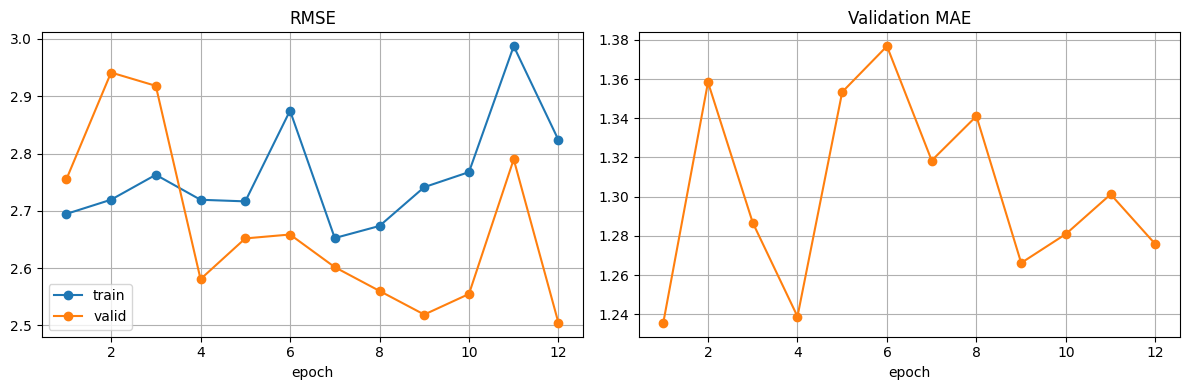

In [25]:
def plot_history(history):
    if len(history["epoch"]) == 0:
        print("No history yet")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["epoch"], history["train_rmse"], marker="o", label="train")
    axes[0].plot(history["epoch"], history["valid_rmse"], marker="o", label="valid")
    axes[0].set_title("RMSE")
    axes[0].set_xlabel("epoch")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(history["epoch"], history["valid_mae"], marker="o", color="tab:orange")
    axes[1].set_title("Validation MAE")
    axes[1].set_xlabel("epoch")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()


plot_history(history)

### Evaluation_Metrics

In [26]:
test_stats = evaluate(
    model=model,
    eval_ds=test_ds,
    loss_fn=loss_fn,
    device=device,
    verbose=True,
)

print("\n[Test]")
print({
    "mse": round(test_stats["mse"], 4),
    "mae": round(test_stats["mae"], 4),
    "rmse": round(test_stats["rmse"], 4),
    "points": test_stats["points"],
})

Eval-test:   0%|          | 0/10 [00:00<?, ?it/s]


[TEST] loaded monster_CA_1.zip in 7.392s
[TEST] 3,049 samples -> 6 batches

[TEST] loaded monster_CA_2.zip in 7.387s
[TEST] 3,049 samples -> 6 batches

[TEST] loaded monster_CA_3.zip in 7.391s
[TEST] 3,049 samples -> 6 batches

[TEST] loaded monster_CA_4.zip in 7.360s
[TEST] 3,049 samples -> 6 batches

[TEST] loaded monster_TX_1.zip in 7.403s
[TEST] 3,049 samples -> 6 batches

[TEST] loaded monster_TX_2.zip in 7.416s
[TEST] 3,049 samples -> 6 batches

[TEST] loaded monster_TX_3.zip in 7.369s
[TEST] 3,049 samples -> 6 batches

[TEST] loaded monster_WI_1.zip in 7.393s
[TEST] 3,049 samples -> 6 batches

[TEST] loaded monster_WI_2.zip in 7.376s
[TEST] 3,049 samples -> 6 batches

[TEST] loaded monster_WI_3.zip in 7.386s
[TEST] 3,049 samples -> 6 batches

[Test]
{'mse': 6.3539, 'mae': 1.2975, 'rmse': 2.5207, 'points': 853720}


### Prediction_Vizualization


[VALID] loaded monster_CA_1.zip in 7.366s
[VALID] 3,049 samples -> 6 batches


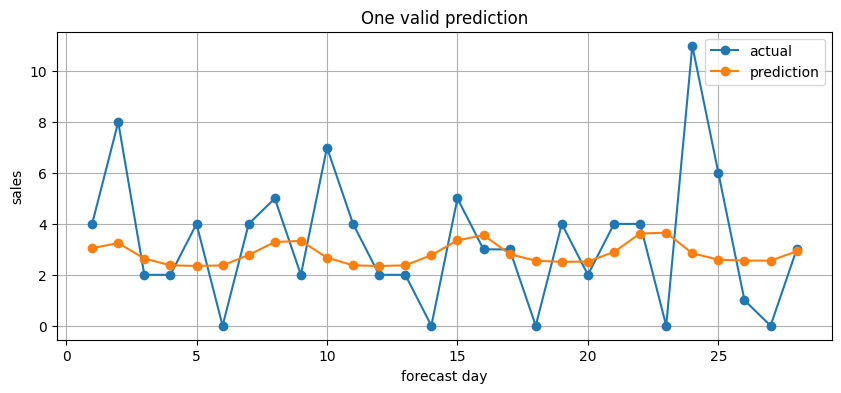

file      : monster_CA_1.zip
series_idx: 1088
t_idx     : 1827


In [28]:
@torch.no_grad()
def plot_one_prediction(model, dataset, device, batch_idx=2, item_idx=64):
    model.eval()

    batches = dataset.get_shard_batches(0)
    batch = batches[batch_idx]
    batch_dev = move_batch_to_device(batch, device)

    pred, agg_weights = model(batch_dev)
    pred = pred.detach().cpu().numpy()
    target = batch["target"].numpy()

    y_pred = pred[item_idx]
    y_true = target[item_idx]

    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(1, CFG.TARGET + 1), y_true, marker="o", label="actual")
    plt.plot(np.arange(1, CFG.TARGET + 1), y_pred, marker="o", label="prediction")
    plt.title(f"One {dataset.split} prediction")
    plt.xlabel("forecast day")
    plt.ylabel("sales")
    plt.grid(True)
    plt.legend()
    plt.show()

    print("file      :", batch["file"])
    print("series_idx:", int(batch["series_idx"][item_idx]))
    print("t_idx     :", int(batch["t_idx"][item_idx]))


plot_one_prediction(model, valid_ds, device)